# Section 1: Importing Libraries and Reading the Dataset
In this experiment, we are analysing the body measurements of adult males and females. We will use NumPy for calculations, Matplotlib for graphs, Pandas for displaying tables, and SciPy for calculating skewness, kurtosis, and correlation coefficients.

The datasets contain seven measurements: weight, standing height, upper arm length, upper leg length, arm circumference, hip circumference, and waist circumference.

1. np.genfromtxt() reads the CSV file and converts it into a NumPy array.

2. delimiter="," tells Python that the values are separated by commas.

3. skip_header skips the comments and column heading in the file.

4. .shape displays the number of rows and columns.

In [1]:
# Importing the required libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import spearmanr
from scipy.stats import pearsonr

# GitHub raw URLs for the datasets

male_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv"

female_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv"

# Reading the male dataset directly from GitHub

male = np.genfromtxt(
    male_url,
    delimiter=",",
    skip_header=55
)

# Reading the female dataset directly from GitHub

female = np.genfromtxt(
    female_url,
    delimiter=",",
    skip_header=19
)

# Printing the shape of both datasets

print("Shape of male dataset:", male.shape)
print("Shape of female dataset:", female.shape)

Shape of male dataset: (4045, 7)
Shape of female dataset: (4221, 7)


# Section 2: Understanding the Columns

Before performing calculations, it is important to understand what each column represents. The column numbers start from zero in Python.

The first column contains weight, the second contains height, and the remaining columns contain different body measurements. We will use these column positions to extract the required data for calculations.

In [2]:
# Column names of the original dataset

column_names = [
    "Weight (kg)",
    "Height (cm)",
    "Upper Arm Length (cm)",
    "Upper Leg Length (cm)",
    "Arm Circumference (cm)",
    "Hip Circumference (cm)",
    "Waist Circumference (cm)"
]

# Printing the column numbers and names

for i in range(len(column_names)):
    print(i, ":", column_names[i])

# Displaying the first five rows of both datasets

print("\nFirst 5 rows of male dataset:")
print(male[:5])

print("\nFirst 5 rows of female dataset:")
print(female[:5])

0 : Weight (kg)
1 : Height (cm)
2 : Upper Arm Length (cm)
3 : Upper Leg Length (cm)
4 : Arm Circumference (cm)
5 : Hip Circumference (cm)
6 : Waist Circumference (cm)

First 5 rows of male dataset:
[[ 59.6 168.6  34.4  41.6  26.7  89.5  71.5]
 [143.4 182.   43.1  46.   49.1 130.1 126.5]
 [ 82.8 161.4  35.   37.5  34.2 105.8 101.7]
 [ 74.3 168.5  40.1  42.4  32.1  97.3  95. ]
 [112.7 176.1  41.3  44.7  42.2 117.6 103.4]]

First 5 rows of female dataset:
[[ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]
 [ 91.1 152.7  33.5  33.   38.5 125.5 103.1]
 [ 73.  161.2  37.4  38.   31.8 106.2  92. ]
 [ 61.7 157.4  38.   34.7  29.  101.   90.5]
 [ 55.4 154.6  34.6  34.   28.3  92.5  73.2]]


# Section 3: Extracting Male and Female Weights

For the next parts of the experiment, we need to compare the weight distributions of males and females. Since weight is stored in the first column, we will extract column zero from both matrices.

1. : means we select all rows.

2. 0 means we select the first column.

3. male[:, 0] extracts all male weights.

4. female[:, 0] extracts all female weights.

We have extracted the weights into separate arrays. These arrays will be used to create histograms, boxplots, and calculate numerical statistics.

In [3]:
# Extracting weights from both datasets

male_weights = male[:, 0]
female_weights = female[:, 0]

# Printing some basic information

print("Number of male participants:", len(male_weights))
print("Number of female participants:", len(female_weights))

print("\nFirst 10 male weights:")
print(male_weights[:10])

print("\nFirst 10 female weights:")
print(female_weights[:10])

Number of male participants: 4045
Number of female participants: 4221

First 10 male weights:
[ 59.6 143.4  82.8  74.3 112.7 127.6 103.3 105.7 191.4  75.4]

First 10 female weights:
[97.1 91.1 73.  61.7 55.4 62.  66.2 75.9 77.2 91.6]


# Section 4: Histograms of Female and Male Weights

A histogram is used to show how frequently different weight values occur. We will create two histograms in one figure using subplot(). The female histogram will be placed at the top, and the male histogram will be placed at the bottom.

Both histograms will have the same x-axis limits so that the weight distributions can be compared fairly.

1. plt.figure() creates the figure.

2. plt.subplot(2, 1, 1) creates the first plot in a figure with two rows and one column.

3. plt.subplot(2, 1, 2) creates the second plot.

4. bins=30 divides the weight range into 30 groups.

5. plt.xlim() makes the x-axis limits identical.

6. plt.tight_layout() prevents the labels and titles from overlapping.

The histograms show how the weights are distributed in both groups. We can compare the areas where most observations occur and check whether the distributions are spread out or have unusually high values.

The exact shape and skewness should be checked from the generated graph and the statistics calculated later.

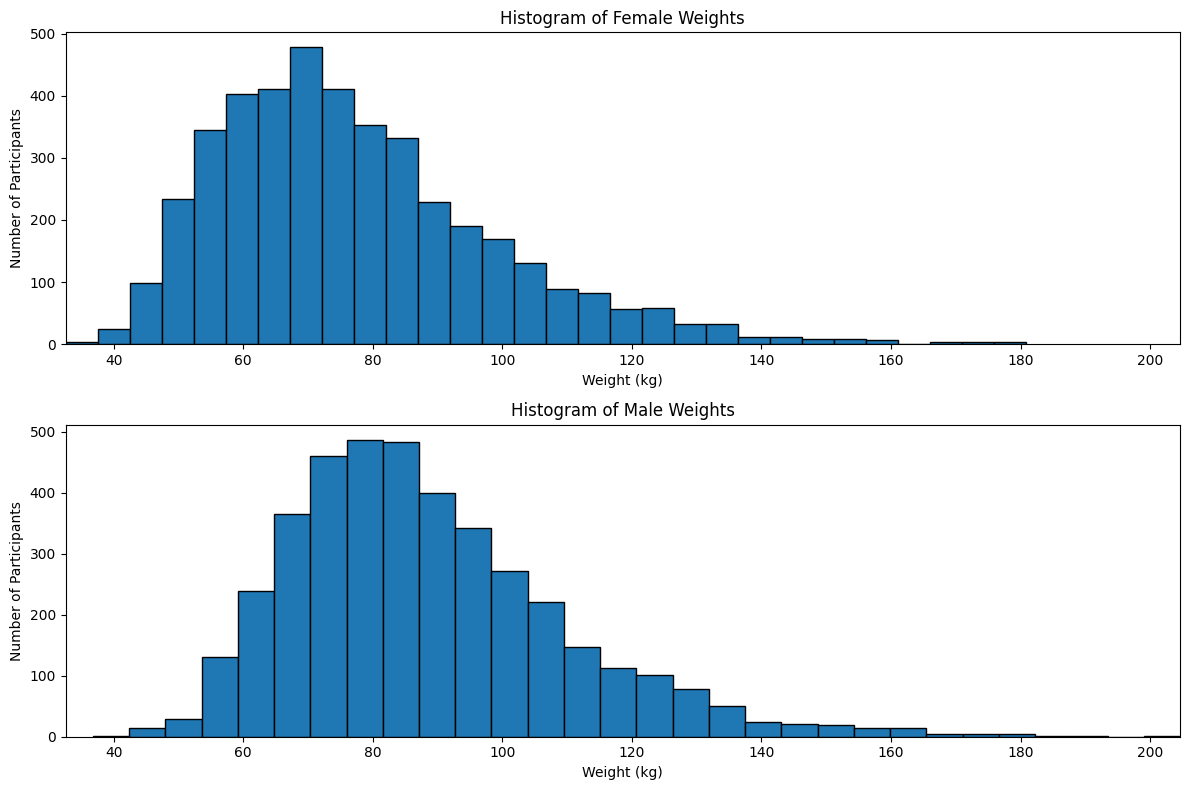

In [4]:
# Finding common x-axis limits

minimum_weight = min(
    np.min(female_weights),
    np.min(male_weights)
)

maximum_weight = max(
    np.max(female_weights),
    np.max(male_weights)
)

# Creating the figure

plt.figure(figsize=(12, 8))

# Top subplot: Female weight histogram

plt.subplot(2, 1, 1)

plt.hist(
    female_weights,
    bins=30,
    edgecolor="black"
)

plt.title("Histogram of Female Weights")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Participants")

# Setting the same x-axis limits

plt.xlim(minimum_weight, maximum_weight)

# Bottom subplot: Male weight histogram

plt.subplot(2, 1, 2)

plt.hist(
    male_weights,
    bins=30,
    edgecolor="black"
)

plt.title("Histogram of Male Weights")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Participants")

# Using the same x-axis limits

plt.xlim(minimum_weight, maximum_weight)

# Adjusting the space between the plots

plt.tight_layout()

# Displaying the figure

plt.show()

# Section 5: Boxplot Comparison of Male and Female Weights

A boxplot provides a quick comparison of the median, lower and upper quartiles, and possible outliers. We will create two boxes side by side for the female and male weight distributions.

From the boxplot, I can observe that the median weight of males is higher than that of females. Both distributions show a wide range of weights and several outliers above the upper whisker. The male weight distribution extends to a higher maximum value. The boxplot helps me compare the central values and spread of weights between the two groups.

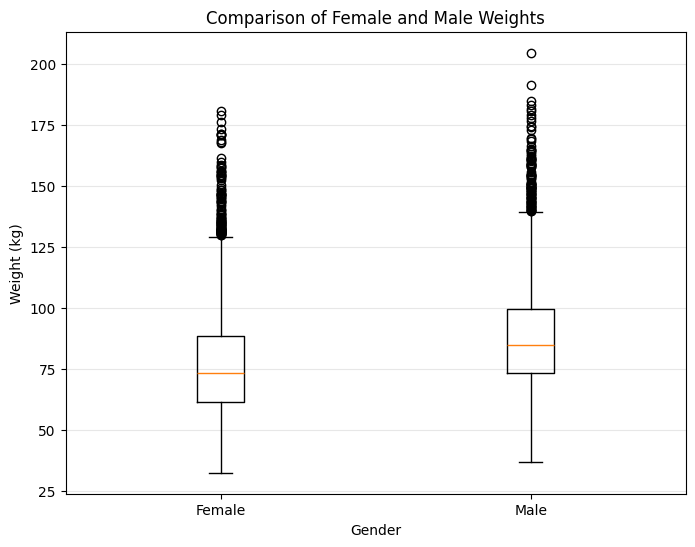

In [18]:
# Creating a boxplot for female and male weights

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        female_weights,
        male_weights
    ],
    tick_labels=[
        "Female",
        "Male"
    ]
)

plt.title("Comparison of Female and Male Weights")

plt.xlabel("Gender")

plt.ylabel("Weight (kg)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# Section 6: Basic Numerical Aggregates of Weight

In this section, we will calculate different statistical measures for both male and female weights.

The measures are divided into three categories:

1. Location: Mean and median.

2. Dispersion: Minimum, maximum, range, variance, and standard deviation.

3. Shape: Skewness and kurtosis.

These values help us understand the weight distributions numerically rather than relying only on graphs.

Explanation:

1. np.mean() calculates the average.

2. np.median() calculates the middle value.

3. np.ptp() calculates the range (maximum minus minimum).

4. np.var() calculates variance.

5. np.std() calculates standard deviation.

6. skew() measures the asymmetry of a distribution.

7. kurtosis() calculates excess kurtosis by default.

8. ddof=1 is used for sample variance and sample standard deviation.

The mean and median help us understand the central weight of each group. Standard deviation shows how much the weights vary around their mean.

If skewness is positive, the distribution has a longer tail towards higher weights. If skewness is negative, the tail extends more towards lower weights. Kurtosis provides information about the shape of the distribution compared with a normal distribution.

The numerical values should be used to support the observations made from the histograms and boxplots.

In [6]:
# Function to calculate basic statistics

def calculate_statistics(weights):

    statistics = {}

    # Measures of location

    statistics["Mean"] = np.mean(weights)
    statistics["Median"] = np.median(weights)

    # Measures of dispersion

    statistics["Minimum"] = np.min(weights)
    statistics["Maximum"] = np.max(weights)
    statistics["Range"] = np.ptp(weights)

    statistics["Variance"] = np.var(
        weights,
        ddof=1
    )

    statistics["Standard Deviation"] = np.std(
        weights,
        ddof=1
    )

    # Measures of shape

    statistics["Skewness"] = skew(weights)

    statistics["Kurtosis"] = kurtosis(
        weights
    )

    return statistics


# Calculating statistics for both groups

female_statistics = calculate_statistics(
    female_weights
)

male_statistics = calculate_statistics(
    male_weights
)


# Creating a table to display the results

statistics_table = pd.DataFrame(
    {
        "Female": female_statistics,
        "Male": male_statistics
    }
)

# Rounding the values for easier reading

statistics_table = statistics_table.round(3)

print(statistics_table)

                     Female     Male
Mean                 77.404   88.407
Median               73.600   85.100
Minimum              32.600   36.800
Maximum             180.900  204.600
Range               148.300  167.800
Variance            464.190  458.824
Standard Deviation   21.545   21.420
Skewness              1.033    0.988
Kurtosis              1.401    1.485


# Section 7: Comparing the Mean and Median

We will compare the mean and median values to understand the central weight of males and females. This also helps us identify whether the distributions may be affected by extreme values.

The mean and median provide two ways to describe the centre of the data. When the mean is greater than the median, it can indicate that some higher values are increasing the average.

We should also consider the histograms and skewness values before making a conclusion about the complete distribution.

In [7]:
# Extracting mean and median values

female_mean = np.mean(female_weights)
female_median = np.median(female_weights)

male_mean = np.mean(male_weights)
male_median = np.median(male_weights)

# Printing the results

print("Female mean:", round(female_mean, 2))
print("Female median:", round(female_median, 2))

print("\nMale mean:", round(male_mean, 2))
print("Male median:", round(male_median, 2))

# Comparing mean and median

print("\nComparison:")

if female_mean > female_median:
    print("Female weights have a mean greater than the median.")
elif female_mean < female_median:
    print("Female weights have a mean lower than the median.")
else:
    print("Female mean and median are equal.")

if male_mean > male_median:
    print("Male weights have a mean greater than the median.")
elif male_mean < male_median:
    print("Male weights have a mean lower than the median.")
else:
    print("Male mean and median are equal.")

Female mean: 77.4
Female median: 73.6

Male mean: 88.41
Male median: 85.1

Comparison:
Female weights have a mean greater than the median.
Male weights have a mean greater than the median.


# Section 8: Adding BMI to the Female Matrix

Body Mass Index (BMI) is calculated using body weight and height. We have to convert height from centimetres to metres before applying the formula.

BMI= Weight(kg)/Height (m)^2
	​

We will calculate BMI for every female participant and add it as the eighth column.

Explanation

1. female[:, 0] extracts the weight column.

2. female[:, 1] extracts the height column.

3. Height is divided by 100 to convert centimetres into metres.

4. np.column_stack() adds the BMI array as a new column.

5. The BMI column has index 7 because Python indexing starts at zero.


The female matrix now contains eight columns. The new column stores the BMI of each participant, which will be used for correlation analysis and for identifying participants with the lowest and highest BMI.

In [8]:
# Extracting female weight and height

female_weight = female[:, 0]

female_height_cm = female[:, 1]

# Converting height from centimetres to metres

female_height_m = female_height_cm / 100

# Calculating BMI

female_bmi = female_weight / (
    female_height_m ** 2
)

# Adding BMI as the eighth column

female = np.column_stack(
    (
        female,
        female_bmi
    )
)

# Printing the updated shape

print("Updated female dataset shape:", female.shape)

# Printing the first 10 BMI values

print("\nFirst 10 BMI values:")
print(female[:10, 7])

Updated female dataset shape: (4221, 8)

First 10 BMI values:
[37.83504078 39.06972037 28.09265496 24.90437849 23.17879132 29.61110588
 23.87973559 31.796902   30.46008939 30.08185483]


# Section 9: Standardising the Female Dataset

Standardisation converts the values in each column into z-scores. This allows measurements with different units to be compared using a common scale.

The formula for a z-score is:

z = (x-μ)/σ
	​


Here, x is the original value, μ is the column mean, and σ is the column standard deviation.

The standardised matrix zfemale contains the z-scores of all eight columns. The mean of each standardised column should be close to zero, and its standard deviation should be close to one.

Standardisation is useful when we want to compare variables such as weight, height, waist circumference, and BMI, which have different units and ranges.

In [9]:
# Calculating the mean of each column

female_mean = np.mean(
    female,
    axis=0
)

# Calculating the standard deviation of each column

female_std = np.std(
    female,
    axis=0
)

# Calculating z-scores

zfemale = (
    female - female_mean
) / female_std

# Displaying the first 5 rows

print("First 5 rows of zfemale:")
print(zfemale[:5])

# Checking the means of standardised columns

print("\nMean of each standardised column:")
print(np.round(np.mean(zfemale, axis=0), 4))

# Checking the standard deviations

print("\nStandard deviation of each column:")
print(np.round(np.std(zfemale, axis=0), 4))

First 5 rows of zfemale:
[[ 0.91429508  0.00895038 -0.56739463  1.13298804  0.55084546  1.08316157
   1.11578462  0.9969677 ]
 [ 0.63577599 -1.05306843 -1.07893145 -1.29349161  1.03221804  1.04475528
   0.265089    1.15617483]
 [-0.2044233   0.15055289  0.5835632   0.26194406 -0.1622991  -0.19064688
  -0.37293272 -0.25927501]
 [-0.7289676  -0.38753664  0.83933161 -0.76464348 -0.66150029 -0.52350135
  -0.45915188 -0.67039085]
 [-1.02141265 -0.78402366 -0.6100227  -0.98240447 -0.78630059 -1.06759039
  -1.45354609 -0.89289859]]

Mean of each standardised column:
[ 0.  0. -0. -0.  0. -0.  0. -0.]

Standard deviation of each column:
[1. 1. 1. 1. 1. 1. 1. 1.]


# Section 10: Creating the Scatterplot Matrix

A scatterplot matrix is used to examine the relationship between several variables at the same time. We will select height, weight, waist circumference, hip circumference, and BMI from the standardised female dataset.

Column Positions
| Column Position | Measurement |
|----------------|-------------|
| 0              | Weight      |
| 1              | Height      |
| 5              | Hip Circumference |
| 6              | Waist Circumference |
| 7              | BMI         |

Explanation:

1. selected_columns contains the column numbers that we need.

2. zfemale[:, selected_columns] extracts these columns.

3. pd.DataFrame() gives names to the variables.

4. scatter_matrix() creates scatterplots for every pair of variables.

5. diagonal="hist" displays a histogram on the diagonal.

The scatterplot matrix allows us to observe whether two variables increase or decrease together. For example, we can check the relationship between weight and BMI, or between waist and hip circumference.

The scatterplots give a visual idea of the relationship, while correlation coefficients will provide numerical values.

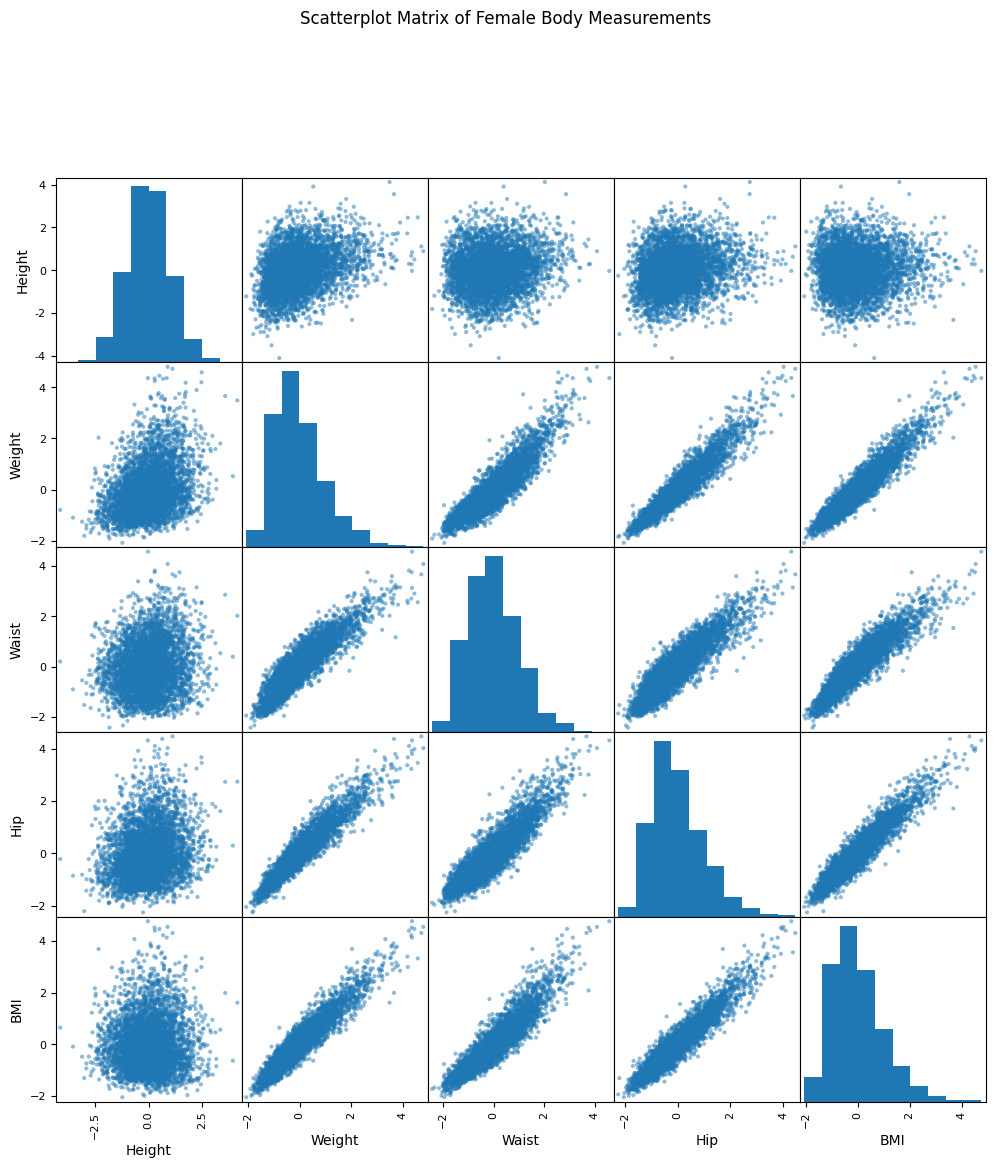

In [10]:
# Selecting the required columns from zfemale

selected_columns = [
    1,  # Height
    0,  # Weight
    6,  # Waist circumference
    5,  # Hip circumference
    7   # BMI
]

# Extracting the selected columns

selected_data = zfemale[
    :,
    selected_columns
]

# Giving names to the selected variables

variable_names = [
    "Height",
    "Weight",
    "Waist",
    "Hip",
    "BMI"
]

# Converting the selected data into a DataFrame

selected_df = pd.DataFrame(
    selected_data,
    columns=variable_names
)

# Creating the scatterplot matrix

pd.plotting.scatter_matrix(
    selected_df,
    figsize=(12, 12),
    diagonal="hist",
    alpha=0.5
)

plt.suptitle(
    "Scatterplot Matrix of Female Body Measurements",
    y=1.02
)

plt.show()

# Section 11: Pearson Correlation Coefficients

Pearson correlation measures the strength and direction of a linear relationship between two variables. Its value ranges from -1 to +1.

1. A value close to +1 indicates a strong positive relationship.

2. A value close to -1 indicates a strong negative relationship.

3. A value close to 0 indicates a weak linear relationship.

The Pearson correlation matrix shows how strongly the selected body measurements are linearly related.

For example, a positive correlation between weight and BMI means that higher weight is generally associated with higher BMI in this dataset. However, the correlation value alone does not prove that one variable causes a change in another.

In [11]:
# Calculating the Pearson correlation matrix

pearson_correlation = selected_df.corr(
    method="pearson"
)

# Displaying the correlation matrix

print("Pearson Correlation Matrix:")

print(
    pearson_correlation.round(3)
)

Pearson Correlation Matrix:
        Height  Weight  Waist    Hip    BMI
Height   1.000   0.345  0.127  0.203  0.033
Weight   0.345   1.000  0.905  0.947  0.946
Waist    0.127   0.905  1.000  0.897  0.921
Hip      0.203   0.947  0.897  1.000  0.944
BMI      0.033   0.946  0.921  0.944  1.000


# Section 12: Spearman Correlation Coefficients

Spearman correlation measures the relationship between two variables using their ranks. It is useful when the relationship is not perfectly linear but still follows an increasing or decreasing pattern.

Spearman correlation is based on the ranking of values instead of their exact numerical differences. We can compare the Pearson and Spearman matrices to see whether the relationships are similar.

If both coefficients have similar values, the relationship may be reasonably consistent. If they differ significantly, the relationship may be affected by non-linear patterns or unusual observations.

In [12]:
# Calculating the Spearman correlation matrix

spearman_correlation = selected_df.corr(
    method="spearman"
)

# Displaying the correlation matrix

print("Spearman Correlation Matrix:")

print(
    spearman_correlation.round(3)
)

Spearman Correlation Matrix:
        Height  Weight  Waist    Hip    BMI
Height   1.000   0.339  0.109  0.205  0.020
Weight   0.339   1.000  0.900  0.947  0.938
Waist    0.109   0.900  1.000  0.888  0.923
Hip      0.205   0.947  0.888  1.000  0.934
BMI      0.020   0.938  0.923  0.934  1.000


# Section 13: Comparing Pearson and Spearman Correlations

In this section, we will display the difference between Pearson and Spearman correlation coefficients. This helps us compare the two methods for the same variables.

The difference table shows how much the two correlation methods vary for each pair of variables. Small differences suggest that the two methods give similar results, while larger differences indicate that the type of relationship or the distribution of values may affect the result.

In [13]:
# Calculating the difference between the two matrices

correlation_difference = (
    pearson_correlation -
    spearman_correlation
)

print("Difference between Pearson and Spearman:")
print(correlation_difference.round(3))

Difference between Pearson and Spearman:
        Height  Weight  Waist    Hip    BMI
Height   0.000   0.007  0.018 -0.003  0.013
Weight   0.007   0.000  0.004 -0.000  0.008
Waist    0.018   0.004  0.000  0.009 -0.002
Hip     -0.003  -0.000  0.009  0.000  0.010
BMI      0.013   0.008 -0.002  0.010  0.000


# Section 14: Calculating Waist-to-Height and Waist-to-Hip Ratios

In this section, we will calculate two body measurement ratios for both males and females.

The waist-to-height ratio is calculated by dividing waist circumference by height. The waist-to-hip ratio is calculated by dividing waist circumference by hip circumference.

WHtR = Waist Circumference/Height
	​

WHR = Waist Circumference/Hip Circumference

The two ratios have been added as new columns to both matrices. The waist-to-height ratio measures waist size relative to height, while the waist-to-hip ratio compares waist size with hip size.

These ratios can be compared between the two groups using boxplots.
	​


In [14]:
# Extracting required measurements for males

male_height = male[:, 1]

male_hip = male[:, 5]

male_waist = male[:, 6]


# Extracting required measurements for females

female_height = female[:, 1]

female_hip = female[:, 5]

female_waist = female[:, 6]


# Calculating male waist-to-height ratio

male_waist_height_ratio = (
    male_waist / male_height
)

# Calculating male waist-to-hip ratio

male_waist_hip_ratio = (
    male_waist / male_hip
)


# Calculating female waist-to-height ratio

female_waist_height_ratio = (
    female_waist / female_height
)

# Calculating female waist-to-hip ratio

female_waist_hip_ratio = (
    female_waist / female_hip
)


# Adding the two ratios to the male matrix

male = np.column_stack(
    (
        male,
        male_waist_height_ratio,
        male_waist_hip_ratio
    )
)


# Adding the two ratios to the female matrix

female = np.column_stack(
    (
        female,
        female_waist_height_ratio,
        female_waist_hip_ratio
    )
)


# Printing the updated shapes

print("Updated male matrix shape:", male.shape)

print("Updated female matrix shape:", female.shape)

Updated male matrix shape: (4045, 9)
Updated female matrix shape: (4221, 10)


# Section 15: Boxplot of Waist-to-Height and Waist-to-Hip Ratios

We will create a boxplot with four boxes to compare the two ratios for males and females. The four groups are male waist-to-height ratio, female waist-to-height ratio, male waist-to-hip ratio, and female waist-to-hip ratio.

The boxplot allows us to compare the median, spread, and possible outliers of the four ratios. We can observe the differences between males and females for each ratio.

The waist-to-height ratio and waist-to-hip ratio have different meanings, so they should be compared within their respective groups rather than treating them as the same measurement.

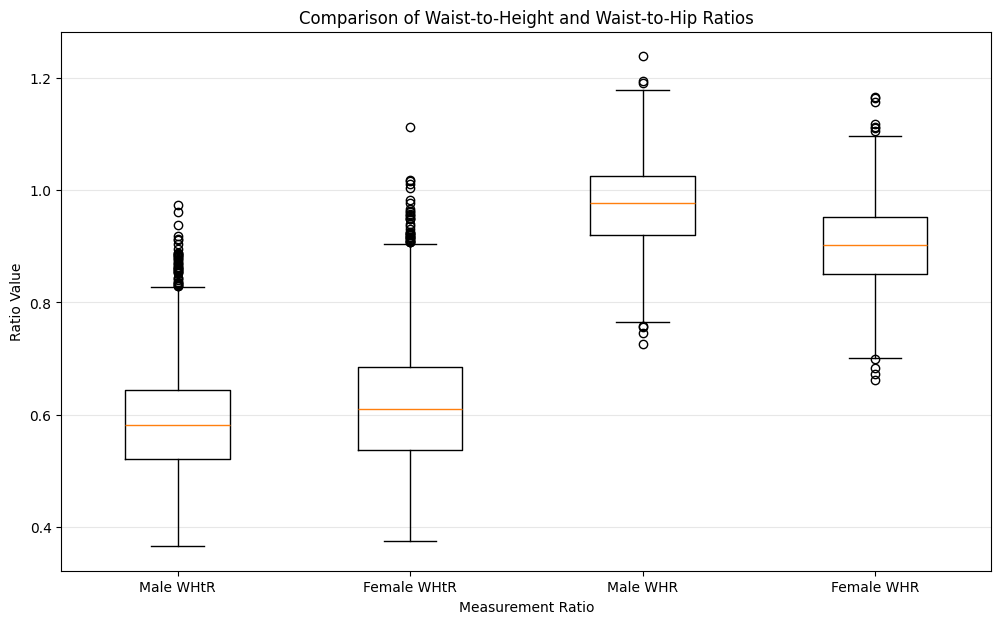

In [19]:
# Creating a boxplot for the four ratios

plt.figure(figsize=(12, 7))

plt.boxplot(
    [
        male_waist_height_ratio,
        female_waist_height_ratio,
        male_waist_hip_ratio,
        female_waist_hip_ratio
    ],
    tick_labels=[
        "Male WHtR",
        "Female WHtR",
        "Male WHR",
        "Female WHR"
    ]
)

plt.title(
    "Comparison of Waist-to-Height and Waist-to-Hip Ratios"
)

plt.xlabel("Measurement Ratio")

plt.ylabel("Ratio Value")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# Section 16: Advantages and Disadvantages of BMI, WHtR and WHR

BMI, waist-to-height ratio, and waist-to-hip ratio are different methods of studying body measurements. Each method has its own benefits and limitations.

**BMI**

Advantages:

1. Easy to calculate using weight and height.

2. Useful for comparing body weight across large groups.

3. Simple to understand and widely used.

Disadvantages:

1. Does not distinguish muscle mass from fat mass.

2. Does not show where body fat is distributed.

3. May not represent body composition accurately for every individual.

**Waist-to-Height Ratio**

Advantages:

1. Uses waist size relative to height.

2. Helps study body fat distribution around the waist.

3. Easy to calculate using two measurements.

Disadvantages:

1. Requires accurate waist and height measurements.

2. Does not directly measure body fat percentage.

3. May be affected by differences in body structure.

**Waist-to-Hip Ratio**

Advantages:

1. Compares waist circumference with hip circumference.

2. Provides information about body proportions.

3. Can be used to compare body fat distribution patterns.

Disadvantages:

1. Requires both waist and hip measurements.

2. Does not directly measure total body fat.

3. Results can be affected by differences in body structure and measurement technique.


Each measurement provides different information. BMI focuses on weight relative to height, while the two ratios focus on waist size in relation to other body measurements. Therefore, one measurement alone cannot fully describe a person's body composition.

# Section 17: Finding Participants with Lowest and Highest BMI

In this section, we will find the five participants with the lowest BMI and the five participants with the highest BMI.

We will use numpy.argsort() to sort the BMI values and obtain the row indices of the required participants. Then we will print their standardised body measurements from zfemale.

Explanation:

1. np.argsort() returns the indices that arrange the BMI values in ascending order.

2. [:5] selects the first five indices.

3. [-5:] selects the last five indices.

4. np.concatenate() combines the two sets of indices.

5. zfemale[selected_indices] selects the corresponding rows from the standardised dataset.



The selected rows show the standardised body measurements of participants with the lowest and highest BMI. The BMI values help us identify the two groups, while the standardised measurements allow us to compare their other body measurements relative to the female dataset.

A high BMI does not necessarily mean that every body measurement will be high. Similarly, a low BMI does not guarantee that all other measurements will be below the average.

In [16]:
# Extracting BMI values from the female matrix

bmi_values = female[:, 7]

# Sorting BMI values and obtaining their indices

sorted_bmi_indices = np.argsort(
    bmi_values
)

# Selecting the 5 participants with the lowest BMI

lowest_bmi_indices = sorted_bmi_indices[:5]

# Selecting the 5 participants with the highest BMI

highest_bmi_indices = sorted_bmi_indices[-5:]

# Combining both sets of indices

selected_indices = np.concatenate(
    (
        lowest_bmi_indices,
        highest_bmi_indices
    )
)

# Printing the indices

print("Indices of lowest BMI participants:")
print(lowest_bmi_indices)

print("\nIndices of highest BMI participants:")
print(highest_bmi_indices)


# Printing their original BMI values

print("\nBMI values of selected participants:")

print(bmi_values[selected_indices])


# Printing standardised measurements

print(
    "\nStandardised measurements of selected participants:"
)

print(
    np.round(
        zfemale[selected_indices],
        3
    )
)

Indices of lowest BMI participants:
[ 262 3478 2126 2753 1209]

Indices of highest BMI participants:
[2268 3022 1472 1104 1096]

BMI values of selected participants:
[14.20340054 14.63273036 14.81882399 15.04456103 15.42130871 64.19895366
 64.7070699  65.11544005 65.33289802 67.03689493]

Standardised measurements of selected participants:
[[-2.08  -1.223 -1.548 -1.169 -2.195 -2.041 -1.942 -2.05 ]
 [-1.88  -0.189 -1.718  0.386 -2.444 -1.855 -2.057 -1.995]
 [-1.537  1.807  0.626  0.573 -2.266 -1.676 -1.706 -1.971]
 [-1.843 -0.26  -0.226  0.511 -2.302 -2.252 -1.856 -1.942]
 [-1.611  0.887 -0.098  0.48  -2.213 -1.829 -1.712 -1.893]
 [ 4.247  0.292  1.862 -0.982  2.369  4.104  3.817  4.396]
 [ 4.456  0.505  1.692 -1.138  3.35   3.983  2.903  4.462]
 [ 4.349  0.278  2.843  1.942  4.366  3.919  3.754  4.515]
 [ 4.804  0.887  2.118  1.817  3.778  4.021  4.082  4.543]
 [ 4.363 -0.034 -0.056 -0.174  2.779  4.316  4.57   4.762]]


# Section 18: Displaying the Selected Participants in a Table

To make the results easier to read, I have chosen to display the standardised measurements of the selected participants in a Pandas DataFrame. This gives the output proper column names.

The table presents the standardised measurements in a readable format. The original row index helps identify the participants in the original dataset, while the z-scores show how their measurements compare with the overall female group.

In [17]:
# Creating names for all standardised columns

zfemale_column_names = [
    "Weight (z-score)",
    "Height (z-score)",
    "Upper Arm Length (z-score)",
    "Upper Leg Length (z-score)",
    "Arm Circumference (z-score)",
    "Hip Circumference (z-score)",
    "Waist Circumference (z-score)",
    "BMI (z-score)"
]

# Creating a DataFrame for the selected rows

selected_zfemale_df = pd.DataFrame(
    zfemale[selected_indices],
    columns=zfemale_column_names
)

# Adding the original row index

selected_zfemale_df.insert(
    0,
    "Original Row Index",
    selected_indices
)

# Displaying the table

print(
    selected_zfemale_df.round(3)
)

   Original Row Index  Weight (z-score)  Height (z-score)  \
0                 262            -2.080            -1.223   
1                3478            -1.880            -0.189   
2                2126            -1.537             1.807   
3                2753            -1.843            -0.260   
4                1209            -1.611             0.887   
5                2268             4.247             0.292   
6                3022             4.456             0.505   
7                1472             4.349             0.278   
8                1104             4.804             0.887   
9                1096             4.363            -0.034   

   Upper Arm Length (z-score)  Upper Leg Length (z-score)  \
0                      -1.548                      -1.169   
1                      -1.718                       0.386   
2                       0.626                       0.573   
3                      -0.226                       0.511   
4                      

# Section 19: Final Conclusion

In this experiment, we analysed the body measurements of adult males and females using NumPy, Matplotlib, and Pandas. We created histograms and boxplots to compare weight distributions and calculated numerical statistics to understand their mean, spread, and shape.

We also calculated BMI, waist-to-height ratio, and waist-to-hip ratio. The scatterplot matrix and correlation coefficients helped us study relationships between different body measurements.

The experiment shows how Python can be used to analyse real-world data and present the results through graphs and numerical calculations.

# Section 20: References

1. Centers for Disease Control and Prevention. (n.d.). *Calculating BMI*. https://www.cdc.gov/growth-chart-training/hcp/using-bmi/calculating-bmi.html

2. World Health Organization. (2011). *Waist circumference and waist–hip ratio: Report of a WHO expert consultation*. https://iris.who.int/bitstreams/ca408ade-05c9-4b7c-8967-6ee5b5e0ccd8/download

3. NumPy Developers. (n.d.). *numpy.genfromtxt*. NumPy documentation. https://numpy.org/doc/stable/reference/generated/numpy.genfromtxt.html

4. SciPy Developers. (n.d.). *scipy.stats.skew*. SciPy documentation. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html

5. Pandas Development Team. (n.d.). *pandas.plotting.scatter_matrix*. pandas documentation. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.plotting.scatter_matrix.html

6. Matplotlib Development Team. (n.d.). *Matplotlib documentation*. https://matplotlib.org/stable/contents.html
